# Input Testing

  Best fold   : 1
  Model path  : checkpoints\fold_1\best_model.pt
✓ DEM transform loaded from spatial_data.npz
  dem_transform : | 30.00, 0.00, 13462980.00|
| 0.00,-30.00, 1647690.00|
| 0.00, 0.00, 1.00|
  dem_crs_epsg  : 3857
✓ Spatial patches loaded: (6400, 11, 4, 4)
  Best macro F1 (saved): 0.5244
✓ Model loaded from: checkpoints\fold_1\best_model.pt
  Device : cpu
  Patches: 6,400 per prediction

[run_inference] triangular_20mm_tp05_drain_soil
  Rasterizing 1011 barangays within DEM extent ...
✓ Saved → checkpoints\triangular_20mm_tp05_drain_soil.tif

GeoTIFF: checkpoints\triangular_20mm_tp05_drain_soil.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood class
  Band 2    : Confidence
  Band 3    : Barangay PSGC Code
  Storm     : triangular  20mm  tpeak=0.5  Drainage=True  Soil=True
✓ Visualization saved → checkpoints\triangular_20mm_tp05_drain_soil_viz.png


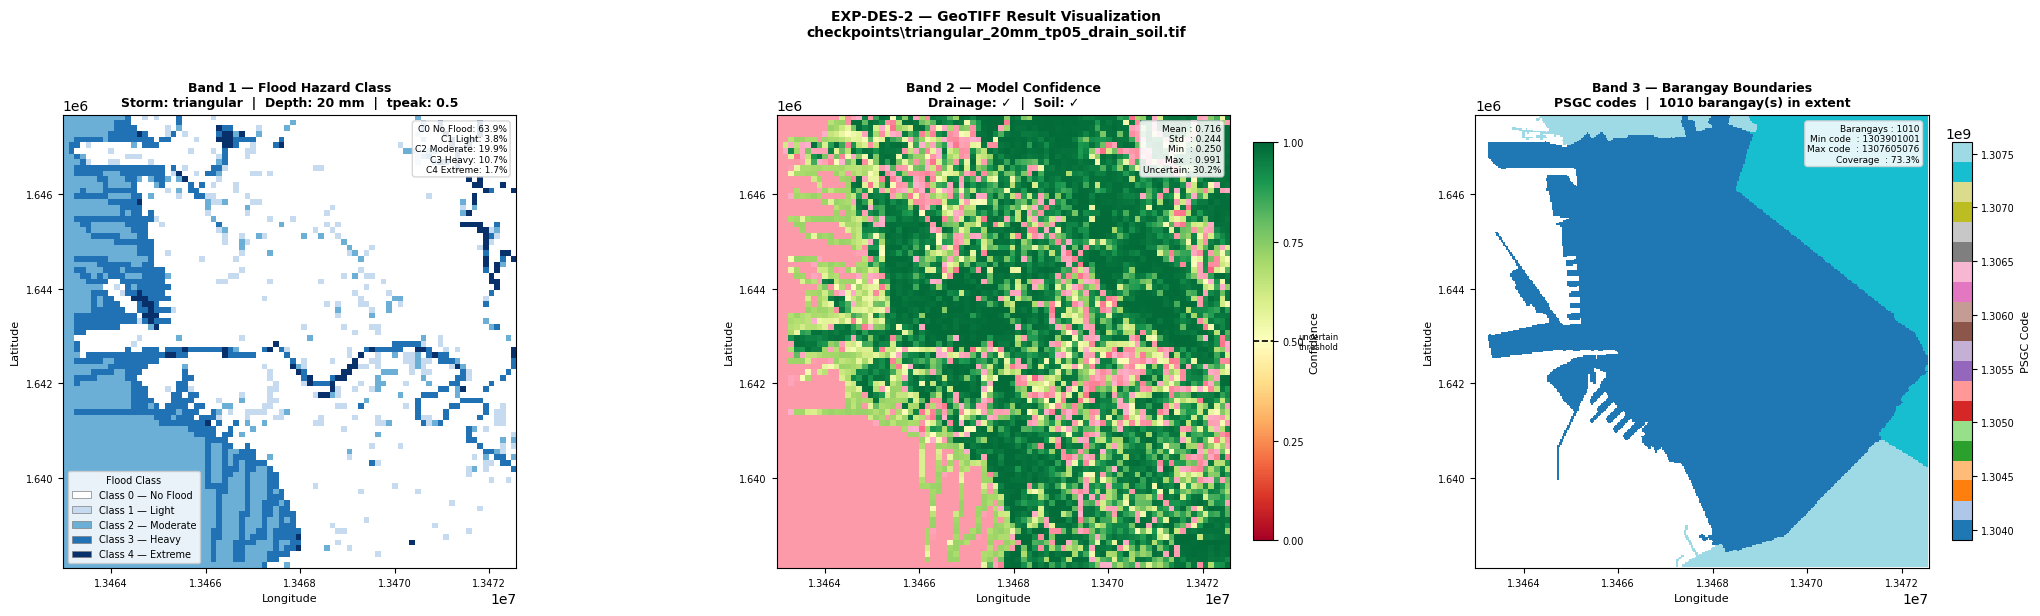

✓ Done  →  checkpoints\triangular_20mm_tp05_drain_soil.tif
          checkpoints\triangular_20mm_tp05_drain_soil_viz.png


In [1]:
from inference import run_inference, FloodInferenceEngine
from config import Config

cfg = Config()

engine = FloodInferenceEngine(
    inference_config_path = 'checkpoints/inference_config.json',
    spatial_data_path     = 'checkpoints/spatial_data.npz',
)

result = run_inference(
    engine      = engine,
    storm_type  = 'triangular',
    depth_mm    = 20,
    tpeak       = 0.5,
    hasDrainage = True,
    hasSoil     = True,
    output_dir  = cfg.train.output_dir,
    geojson_path = 'manila_barangay_geojson.geojson',  
)


In [2]:
import geopandas as gpd
import pandas as pd

_GEOJSON_PATH = 'manila_barangay_geojson.geojson'
_CITY_LABEL = {'PH1303901': 'Manila City', 'PH1307401': 'Mandaluyong', 'PH1307404': 'Marikina', 'PH1307405': 'Pasig',
    'PH1307501': 'Las Piñas', 'PH1307503': 'Parañaque', 'PH1307602': 'San Juan', 'PH1307605': 'Taguig'}

def _build_barangay_lookup(geojson_path: str) -> dict:
    gdf = gpd.read_file(geojson_path)
    gdf['adm3_pcode'] = gdf['adm3_pcode'].astype(str)

    gdf_all = gdf.dropna(subset=['psgc_code']).copy()
    gdf_all['psgc_int'] = gdf_all['psgc_code'].astype(float).astype(int)

    lookup = {}
    for _, row in gdf_all.iterrows():
        psgc = int(row['psgc_int'])
        city = _CITY_LABEL.get(str(row['adm3_pcode']), str(row['adm3_pcode']))
        
        name = row['adm4_en'] if pd.notna(row['adm4_en']) else f'Barangay (PSGC {psgc})'

        lookup[psgc] = {
            'name'      : name,
            'city'      : city,
            'adm4_pcode': row['adm4_pcode'] if pd.notna(row.get('adm4_pcode')) else '',
            'adm3_pcode': row['adm3_pcode'],
            'area_sqkm' : float(row['shape_sqkm']) if pd.notna(row.get('shape_sqkm')) else 0.0,
        }
    return lookup

BARANGAY_LOOKUP = _build_barangay_lookup(_GEOJSON_PATH)

print(f'BARANGAY_LOOKUP ready  : {len(BARANGAY_LOOKUP):,} entries')
print(f'PSGC range             : {min(BARANGAY_LOOKUP):,} – {max(BARANGAY_LOOKUP):,}')
print(f'Cities                 : {sorted(set(v["city"] for v in BARANGAY_LOOKUP.values()))}')


BARANGAY_LOOKUP ready  : 4,560 entries
PSGC range             : 330,100,001 – 1,999,908,008
Cities                 : ['Las Piñas', 'Mandaluyong', 'Manila City', 'Marikina', 'None', 'Parañaque', 'Pasig', 'San Juan', 'Taguig']
